## DS ASSIGNMENT - Pranay Maheshwaram

## Performing EDA

In [1]:
import pandas as pd
import numpy as np

base = "/kaggle/input/datasets/pranaymaheshwaram/ds-assignmentsoulpage/"

orders = pd.read_csv(f'{base}Train/orders.csv', low_memory=False)
train_cust = pd.read_csv(f'{base}Train/train_customers.csv')
train_loc = pd.read_csv(f'{base}Train/train_locations.csv')
vendors = pd.read_csv(f'{base}Train/vendors.csv')
test_cust = pd.read_csv(f'{base}Test/test_customers.csv')
test_loc = pd.read_csv(f'{base}Test/test_locations.csv')

In [2]:
print('=== SHAPES ===')
print(f'orders: {orders.shape}')
print(f'train_customers: {train_cust.shape}')
print(f'train_locations: {train_loc.shape}')
print(f'vendors: {vendors.shape}')
print(f'test_customers: {test_cust.shape}')
print(f'test_locations: {test_loc.shape}')

=== SHAPES ===
orders: (135303, 26)
train_customers: (34674, 8)
train_locations: (59503, 5)
vendors: (100, 59)
test_customers: (9768, 8)
test_locations: (16720, 5)


In [3]:
print('=== ORDERS - nulls ===')
print(orders.isnull().sum())

=== ORDERS - nulls ===
order_id                              70
customer_id                            0
item_count                          6925
grand_total                            0
payment_mode                           0
promo_code                        130998
vendor_discount_amount                 0
promo_code_discount_percentage     69423
is_favorite                        35195
is_rated                               0
vendor_rating                      90083
driver_rating                          0
deliverydistance                       0
preparationtime                    55560
delivery_time                     130180
order_accepted_time                48348
driver_accepted_time               88845
ready_for_pickup_time              51054
picked_up_time                     51438
delivered_time                     49562
delivery_date                      99759
vendor_id                              0
created_at                             0
LOCATION_NUMBER                   

We have so much missing data...

In [4]:
print('=== ORDERS - numeric summary ===')
print(orders[['item_count','grand_total','deliverydistance','preparationtime','delivery_time','vendor_rating','driver_rating']].describe())

=== ORDERS - numeric summary ===
          item_count    grand_total  deliverydistance  preparationtime  \
count  128378.000000  135303.000000     135303.000000     79743.000000   
mean        2.405404      15.374513          4.104255        43.181721   
std         1.645332      12.556177          4.361884         7.107582   
min         1.000000       0.000000          0.000000        25.000000   
25%         1.000000       8.200000          0.000000        40.000000   
50%         2.000000      11.700000          2.900000        45.000000   
75%         3.000000      18.500000          7.920000        45.000000   
max        68.000000     783.800000         19.810000        90.000000   

       vendor_rating  driver_rating  
count   45220.000000  135303.000000  
mean        1.959730       0.675366  
std         2.313294       1.667261  
min         0.000000       0.000000  
25%         0.000000       0.000000  
50%         0.000000       0.000000  
75%         5.000000       0.00000

In [5]:
print('=== ORDERS - value counts ===')
print('payment_mode:', orders['payment_mode'].value_counts().to_dict())
print('is_favorite:', orders['is_favorite'].value_counts().to_dict())
print('is_rated:', orders['is_rated'].value_counts().to_dict())
print('LOCATION_TYPE:', orders['LOCATION_TYPE'].value_counts().to_dict())

=== ORDERS - value counts ===
payment_mode: {1: 104714, 2: 22079, 4: 6696, 3: 1361, 5: 453}
is_favorite: {'No': 98449, 'Yes': 1659}
is_rated: {'No': 115194, 'Yes': 20109}
LOCATION_TYPE: {'Home': 51484, 'Work': 18257, 'Other': 16669}


In [6]:
# Orders per vendor
opv = orders.groupby('vendor_id').size()
print()
print('=== Orders per vendor ===')
print(opv.describe())
print(opv.sort_values(ascending=False).head(10))


=== Orders per vendor ===
count     100.00000
mean     1353.03000
std      1178.32182
min       474.00000
25%       730.50000
50%       941.00000
75%      1529.50000
max      7807.00000
dtype: float64
vendor_id
113    7807
105    5562
79     5117
84     5001
78     4643
83     3684
386    3280
86     2837
846    2559
106    2263
dtype: int64


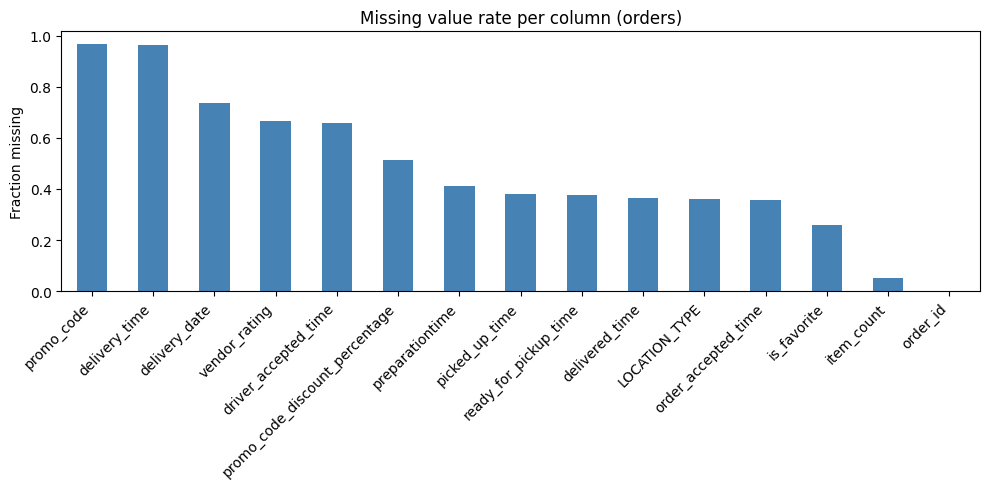

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

null_pct = orders.isnull().mean().sort_values(ascending=False)
null_pct = null_pct[null_pct > 0]

plt.figure(figsize=(10, 5))
null_pct.plot(kind='bar', color='steelblue')
plt.title('Missing value rate per column (orders)')
plt.ylabel('Fraction missing')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [8]:
# Unique customers in orders vs train_customers
print()
print('Unique customers in orders:', orders['customer_id'].nunique())
print('Unique customers in train_customers:', train_cust['customer_id'].nunique())
print('Test customers who appear in train orders:', test_cust['customer_id'].isin(orders['customer_id']).sum())


Unique customers in orders: 27445
Unique customers in train_customers: 34523
Test customers who appear in train orders: 0


In [9]:
# Customers per location
print()
print('=== Locations per customer (train) ===')
lpc = train_loc.groupby('customer_id').size()
print(lpc.describe())
print('location_type nulls in train_loc:', train_loc['location_type'].isnull().sum(), '/', len(train_loc))


=== Locations per customer (train) ===
count    35400.000000
mean         1.680876
std          1.178542
min          1.000000
25%          1.000000
50%          1.000000
75%          2.000000
max         30.000000
dtype: float64
location_type nulls in train_loc: 27209 / 59503


In [10]:
# Vendors
print()
print('=== Vendor info ===')
print('vendor_category_en:', vendors['vendor_category_en'].value_counts().to_dict())
print('Top vendor tags:', vendors['vendor_tag_name'].dropna().str.split(',').explode().str.strip().value_counts().head(15).to_dict())
print('vendor_rating stats:', vendors['vendor_rating'].describe().to_dict())


=== Vendor info ===
vendor_category_en: {'Restaurants': 88, 'Sweets & Bakes': 12}
Top vendor tags: {'Desserts': 44, 'Sandwiches': 42, 'Burgers': 40, 'Salads': 33, 'American': 27, 'Free Delivery': 24, 'Breakfast': 24, 'Fries': 20, 'Fresh Juices': 17, 'Pasta': 16, 'Kids meal': 15, 'Soups': 14, 'Mojitos': 13, 'Arabic': 11, 'Milkshakes': 11}
vendor_rating stats: {'count': 100.0, 'mean': 4.35, 'std': 0.24883567252142924, 'min': 3.2, '25%': 4.2, '50%': 4.4, '75%': 4.5, 'max': 4.8}


We can prioritize the vendors with more tags, when we are doing our final prediction. 

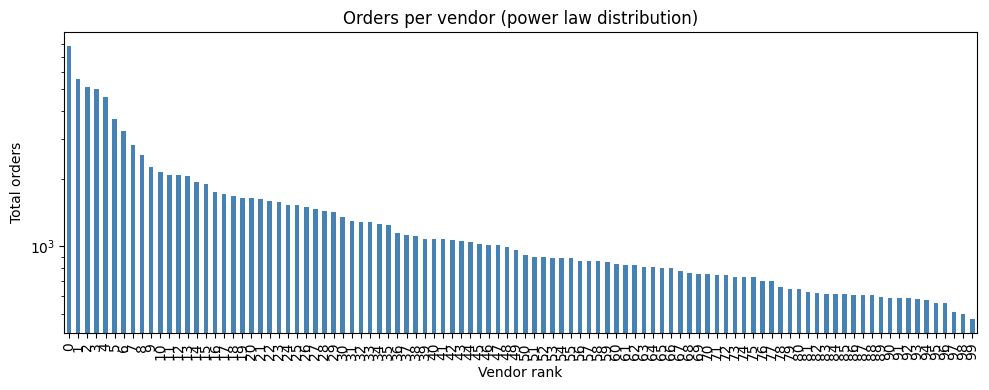

In [11]:
plt.figure(figsize=(10, 4))
opv.sort_values(ascending=False).reset_index(drop=True).plot(kind='bar', color='steelblue')
plt.title('Orders per vendor (power law distribution)')
plt.xlabel('Vendor rank')
plt.ylabel('Total orders')
plt.yscale('log')
plt.tight_layout()
plt.show()

The vendor who's popular gets more orders from customers. And, this distribution is highly skewed. 

In [12]:
# Target distribution: unique (customer, vendor) pairs 
unique_cv = orders[['customer_id','vendor_id']].drop_duplicates()
print('=== Target (customer ordered from vendor) ===')
print('Total unique (customer, vendor) pairs (positives):', len(unique_cv))
print('Total customers who ordered:', orders['customer_id'].nunique())
print('Vendors:', orders['vendor_id'].nunique())
print('Max possible pairs:', orders['customer_id'].nunique() * orders['vendor_id'].nunique())
print('Sparsity:', 1 - len(unique_cv)/(orders['customer_id'].nunique() * orders['vendor_id'].nunique()))

=== Target (customer ordered from vendor) ===
Total unique (customer, vendor) pairs (positives): 71484
Total customers who ordered: 27445
Vendors: 100
Max possible pairs: 2744500
Sparsity: 0.9739537256330844


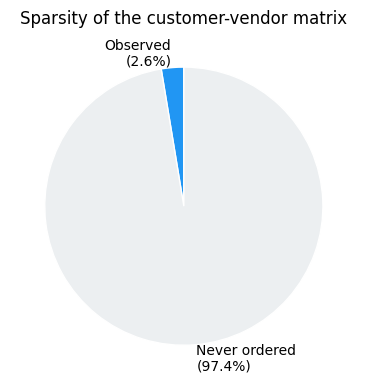

In [13]:
fig, ax = plt.subplots(figsize=(5, 4))
ax.pie([71484, 2744500 - 71484],
       labels=['Observed\n(2.6%)', 'Never ordered\n(97.4%)'],
       colors=['#2196F3', '#ECEFF1'],
       startangle=90, wedgeprops={'edgecolor': 'white'})
ax.set_title('Sparsity of the customer-vendor matrix')
plt.tight_layout()
plt.show()

As we can see, our data is highly sparse. Just 2.6% of observed customers have ordered something. 

In [14]:
# How many vendors does a customer typically order from?
vppc = unique_cv.groupby('customer_id').size()
print()
print('=== Vendors per customer ===')
print(vppc.describe())
print('Customers who ordered from only 1 vendor:', (vppc==1).sum())
print('Customers who ordered from 5+ vendors:', (vppc>=5).sum())

# grand_total distribution
print()
print('=== grand_total (excl. outliers) ===')
q = orders['grand_total']
print(q[q<100].describe())
print('Orders with grand_total=0:', (q==0).sum())


=== Vendors per customer ===
count    27445.000000
mean         2.604627
std          2.519873
min          1.000000
25%          1.000000
50%          2.000000
75%          3.000000
max         33.000000
dtype: float64
Customers who ordered from only 1 vendor: 12888
Customers who ordered from 5+ vendors: 4179

=== grand_total (excl. outliers) ===
count    135077.000000
mean         15.181548
std          11.410629
min           0.000000
25%           8.200000
50%          11.700000
75%          18.200000
max          99.800000
Name: grand_total, dtype: float64
Orders with grand_total=0: 683


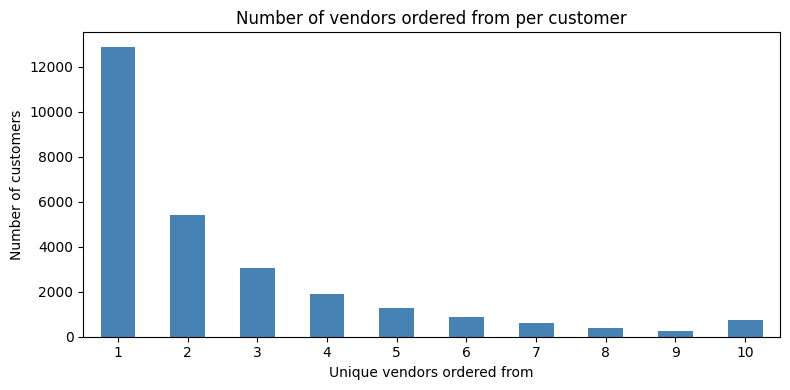

In [15]:
plt.figure(figsize=(8, 4))
vppc.clip(upper=10).value_counts().sort_index().plot(kind='bar', color='steelblue')
plt.title('Number of vendors ordered from per customer')
plt.xlabel('Unique vendors ordered from')
plt.ylabel('Number of customers')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [16]:
# Gender distribution
print()
print('=== Customer gender ===')
print('Train:', train_cust['gender'].value_counts().to_dict())
print('Test:', test_cust['gender'].value_counts().to_dict())

# Language
print()
print('Language train:', train_cust['language'].value_counts().to_dict())


=== Customer gender ===
Train: {'Male': 17815, 'male': 2914, 'Female': 1761, 'Female  ': 13, 'Male  ': 9, 'Female   ': 2, '?????': 2, 'Female ': 2, 'Female    ': 1, '  ': 1}
Test: {'Male': 5021, 'male': 777, 'Female': 514, 'Female  ': 6, 'Female ': 2, 'Male  ': 1}

Language train: {'EN': 21099}


In [17]:
# Repeat orders - same customer same vendor
repeat = orders.groupby(['customer_id','vendor_id']).size()
print()
print('=== Repeat orders (same cust+vendor) === Loyal Customers == ')
print(repeat.describe())
print('(cust,vendor) pairs with 3+ orders:', (repeat>=3).sum())


=== Repeat orders (same cust+vendor) === Loyal Customers == 
count    71484.000000
mean         1.892773
std          2.337107
min          1.000000
25%          1.000000
50%          1.000000
75%          2.000000
max        141.000000
dtype: float64
(cust,vendor) pairs with 3+ orders: 12255


### Key Observations
- Cold-start problem... test customers have 0 overlap with training orders. Pure collaborative filtering won't work alone.
- High sparsity.. 97.4% of (customer, vendor) pairs are unobserved in training data.
- delivery_time (96% null), promo_code (97% null), vendor_rating in orders (67% null) are mostly unusable as raw features.
- Gender needs cleaning... "Male"/"male"/"Male " are separate values. Needs normalisation before use.
- Locations: 46% of train_locations have null location_type. GPS outliers also noted (masked lat/lon values far from cluster).
- Vendor popularity is highly skewed.. top 10 vendors account for a disproportionate share of orders. Good signal for a popularity baseline.

So, we can predict the choice of the customer based on these factors: 
* Distance - usually people order from closest restaurants
* Ratings & Popularity - people are attracted to ratings and reviews.. But, We have 100 vendors.. 
* Location Type - word or home: This affects the ordering patterns...
* Vendor Cuisine Tags - Broad appeal cuisines attract people..

So, we will build our predictive model based on above factors. And, before we build we will finish some data cleaning and introduce some features that we need.

## Data cleaning and Feature Engineering

In [18]:
#building vendor order status
vendor_order_stats = orders.groupby("vendor_id").agg(
    vendor_total_orders    = ("order_id",      "count"),
    vendor_unique_customers= ("customer_id",   "nunique"),
    vendor_avg_spend       = ("grand_total",   "mean"),
    vendor_favorite_rate   = ("is_favorite",   lambda x: (x == "Yes").mean()),
).reset_index()
#adding new feature "vendor popularity rank".. that ranks the vendor with most orders on the top.
vendor_order_stats["vendor_pop_rank"] = (
    vendor_order_stats["vendor_total_orders"].rank(ascending=False)
)

In [19]:
vendor_meta = vendors[[
    "id", "vendor_rating", "delivery_charge", "serving_distance",
    "prepration_time", "vendor_category_en", "vendor_tag_name",
    "latitude", "longitude"
]].copy()
vendor_meta.columns = [
    "vendor_id", "vendor_rating_meta", "delivery_charge", "serving_distance",
    "prepration_time", "vendor_category", "vendor_tags", "vendor_lat", "vendor_lon"
]

In [20]:
# Number of cuisine tags — more tags = more variety
vendor_meta["vendor_tag_count"] = (
    vendor_meta["vendor_tags"].fillna("").apply(lambda x: len(x.split(",")) if x else 0)
)
vendor_meta["is_restaurant"] = (vendor_meta["vendor_category"] == "Restaurants").astype(int)


In [21]:
# Merge order stats with metadata
vf = vendor_order_stats.merge(
    vendor_meta[[
        "vendor_id", "vendor_rating_meta", "delivery_charge", "serving_distance",
        "prepration_time", "vendor_tag_count", "is_restaurant", "vendor_lat", "vendor_lon"
    ]],
    on="vendor_id", how="left"
)
 
print(f"  Vendor feature table: {vf.shape}")

  Vendor feature table: (100, 14)


In [22]:
print("Building customer order features...")
#These are for train set, for test customers these will be 0 as it is a cold start
cust_order_stats = orders.groupby("customer_id").agg(
    cust_total_orders  = ("order_id",    "count"),
    cust_unique_vendors= ("vendor_id",   "nunique"),
    cust_avg_spend     = ("grand_total", "mean"),
).reset_index()
 
print(f"  Customer order feature table: {cust_order_stats.shape}")

Building customer order features...
  Customer order feature table: (27445, 4)


In [23]:
#cleaning the gender columns
def clean_customers(df):
    df = df.copy()
    df["gender"] = (
        df["gender"].str.strip().str.lower()
        .map({"male": 0, "female": 1})
        .fillna(-1).astype(int)
    )
    return df[["customer_id", "gender", "verified"]]
 
train_cust_clean = clean_customers(train_cust)
test_cust_clean  = clean_customers(test_cust)

In [24]:
# Clipping GPS outliers (masked coords have noise), encoding location type. 
def clean_locations(df):
    df = df.copy()
    df["location_number"] = df["location_number"].astype(int)
    # Clip top/bottom 1% to remove GPS noise
    for col in ["latitude", "longitude"]:
        q1, q3 = df[col].quantile(0.01), df[col].quantile(0.99)
        df[col] = df[col].clip(q1, q3)
    df["location_type_enc"] = (
        df["location_type"].map({"Home": 0, "Work": 1, "Other": 2}).fillna(-1).astype(int)
    )
    return df
 
train_loc_c = clean_locations(train_loc)
test_loc_c  = clean_locations(test_loc)
 
def aggregate_locations(df):
    """Per-customer: how many locations, and the first location's coords."""
    return df.groupby("customer_id").agg(
        cust_num_locs = ("location_number", "count"),
        cust_lat      = ("latitude",        "first"),
        cust_lon      = ("longitude",       "first"),
    ).reset_index()
 
train_loc_agg = aggregate_locations(train_loc_c)
test_loc_agg  = aggregate_locations(test_loc_c)

In [25]:
#customer - vendor interaction features
cv = orders.groupby(["customer_id", "vendor_id"]).agg(
    cv_order_count = ("order_id",    "count"),
    cv_avg_spend   = ("grand_total", "mean"),
    cv_is_favorite = ("is_favorite", lambda x: int((x == "Yes").any())),
    cv_is_rated    = ("is_rated",    lambda x: int((x == "Yes").any())),
).reset_index()
 
# This column is our training TARGET:
# 1 = customer has ordered from this vendor at least once
cv["target"] = 1
 
print(f"  Positive (customer, vendor) pairs: {len(cv):,}")

  Positive (customer, vendor) pairs: 71,484


In [26]:
# Distance Features
# Computing Euclidean distance between each customer location and each vendor.
# The coordinates are masked but nearby points remain nearby, so distance is still a valid proximity signal.
# Chunked to avoid memory explosion from the full cross-join...
 
print("Computing location-to-vendor distances (chunked)...")
 
vendor_coords = vf[["vendor_id", "vendor_lat", "vendor_lon"]].copy()
 
def compute_distances(loc_df, vc_df, chunk_size=200):
    """
    For each (customer, location_number), compute distance to every vendor.
    chunk_size: number of unique location rows to process at once.
    """
    results = []
    loc_rows = loc_df[["customer_id", "location_number", "latitude", "longitude"]].drop_duplicates()
    vc = vc_df.copy()
 
    for i in range(0, len(loc_rows), chunk_size):
        chunk = loc_rows.iloc[i : i + chunk_size].copy()
        chunk["_key"] = 1
        vc["_key"] = 1
        merged = chunk.merge(vc, on="_key").drop("_key", axis=1)
        merged["dist"] = np.sqrt(
            (merged["latitude"]  - merged["vendor_lat"]) ** 2 +
            (merged["longitude"] - merged["vendor_lon"]) ** 2
        )
        results.append(merged[["customer_id", "location_number", "vendor_id", "dist"]])
 
    return pd.concat(results, ignore_index=True)
 
train_dist = compute_distances(train_loc_c, vendor_coords)
test_dist  = compute_distances(test_loc_c,  vendor_coords)
 
print(f"  Train distances: {train_dist.shape}")
print(f"  Test distances:  {test_dist.shape}")
 
#ASSEMBLING THE DATA
# Create all (customer × location × vendor) triplets, then join all features.
 
print("\nAssembling train dataset...")
 
all_vendor_ids = pd.DataFrame({"vendor_id": vendors["id"].unique()})
 
def build_triplets(loc_df):
    """Cross-join every (customer, location) with every vendor."""
    pairs = loc_df[["customer_id", "location_number"]].drop_duplicates()
    pairs["_key"] = 1
    vdf = all_vendor_ids.copy()
    vdf["_key"] = 1
    return pairs.merge(vdf, on="_key").drop("_key", axis=1)

Computing location-to-vendor distances (chunked)...
  Train distances: (5950300, 4)
  Test distances:  (1672000, 4)

Assembling train dataset...


In [27]:
train_full = build_triplets(train_loc_c)
 
# Attach target + customer vendor interaction features
train_full = train_full.merge(cv, on=["customer_id", "vendor_id"], how="left")
train_full["target"] = train_full["target"].fillna(0).astype(int)
for col in ["cv_order_count", "cv_avg_spend", "cv_is_favorite", "cv_is_rated"]:
    train_full[col] = train_full[col].fillna(0)
 
# Attach vendor features
train_full = train_full.merge(vf, on="vendor_id", how="left")
 
# Attach customer order stats + demographics + location aggregates
train_full = train_full.merge(cust_order_stats,  on="customer_id", how="left")
train_full = train_full.merge(train_cust_clean,   on="customer_id", how="left")
train_full = train_full.merge(train_loc_agg,      on="customer_id", how="left")
 
# Attach distance
train_full = train_full.merge(train_dist, on=["customer_id", "location_number", "vendor_id"], how="left")
 
# Attach location type for this specific (customer, location_number)
loc_type_train = train_loc_c[["customer_id", "location_number", "location_type_enc"]].drop_duplicates()
train_full = train_full.merge(loc_type_train, on=["customer_id", "location_number"], how="left")
 
# Fill remaining nulls for customers with no order history
for col in ["cust_total_orders", "cust_unique_vendors", "cust_avg_spend"]:
    train_full[col] = train_full[col].fillna(0)
train_full["gender"] = train_full["gender"].fillna(-1).astype(int)
 
print(f"  Train shape:      {train_full.shape}")
print(f"  Positive rate:    {train_full['target'].mean():.3%}")
print(f"  Positive count:   {train_full['target'].sum():,}")
 

  Train shape:      (5969200, 31)
  Positive rate:    3.128%
  Positive count:   186,706


In [28]:
# ── Test ─────────────────────────────────────────────────────────────────────
print("Assembling test dataset...")
 
test_full = build_triplets(test_loc_c)
 
# Create submission key
test_full["CID X LOC_NUM X VENDOR"] = (
    test_full["customer_id"] + " X " +
    test_full["location_number"].astype(str) + " X " +
    test_full["vendor_id"].astype(str)
)
 
# Attach vendor features + demographics + location aggregates
test_full = test_full.merge(vf,             on="vendor_id",   how="left")
test_full = test_full.merge(test_cust_clean, on="customer_id", how="left")
test_full = test_full.merge(test_loc_agg,    on="customer_id", how="left")
test_full = test_full.merge(test_dist, on=["customer_id", "location_number", "vendor_id"], how="left")
 
loc_type_test = test_loc_c[["customer_id", "location_number", "location_type_enc"]].drop_duplicates()
test_full = test_full.merge(loc_type_test, on=["customer_id", "location_number"], how="left")
 
# Cold-start: no order history for test customers
for col in ["cust_total_orders", "cust_unique_vendors", "cust_avg_spend",
            "cv_order_count", "cv_avg_spend", "cv_is_favorite", "cv_is_rated"]:
    test_full[col] = 0.0
test_full["gender"] = test_full["gender"].fillna(-1).astype(int)
 
print(f"  Test shape: {test_full.shape}")
 

Assembling test dataset...
  Test shape: (1673600, 31)


In [29]:
# DEFINING FEATURE COLUMNS
"""
cv_* (order history) features are included in training but will be 0 for test customers
The model learns their weight naturally and will fall back to vendor/location 
signals for cold-start users.
"""
 
FEATURE_COLS = [
    # Vendor signals (most important for cold-start)
    "vendor_total_orders",
    "vendor_unique_customers",
    "vendor_avg_spend",
    "vendor_favorite_rate",
    "vendor_pop_rank",
    "vendor_rating_meta",
    "delivery_charge",
    "serving_distance",
    "prepration_time",
    "vendor_tag_count",
    "is_restaurant",
    # Customer-vendor history (leaky in train, always 0 in test)
    # "cv_order_count",
    # "cv_avg_spend",
    # "cv_is_favorite",
    # "cv_is_rated",
    # Customer profile
    "cust_total_orders",
    "cust_unique_vendors",
    # "cust_avg_spend", - dropping coz test customers have 0
    "gender",
    "verified",
    "cust_num_locs",
    # Location signals
    "dist",
    "location_type_enc",
]

In [30]:
#splitting the data
print("\nSplitting by customer (20% held out as validation)...")
 
all_custs = train_full["customer_id"].unique()
np.random.seed(42)
val_custs = set(np.random.choice(all_custs, size=int(len(all_custs) * 0.2), replace=False))
 
tr_mask  = ~train_full["customer_id"].isin(val_custs)
val_mask =  train_full["customer_id"].isin(val_custs)
 
train_tr  = train_full[tr_mask].copy()
train_val = train_full[val_mask].copy()


Splitting by customer (20% held out as validation)...


SO, In our ~600k pair samples of cv... We have very little positives..
Our training data has two types of negatives:
* Hard negatives: vendors the customer could have ordered from (nearby, good rating, open) but chose not to. These are genuinely informative. They teach the model why some vendors are rejected even when accessible.
* Easy negatives: vendors that are far away, closed, or irrelevant. The model figures these out in 2 seconds. They add no learning value but consume memory and compute.

At 6 million rows, roughly 90%+ are easy negatives. Keeping all of them doesn't make the model smarter — it just makes it slower and causes it to overfit to the trivial pattern of "far away = 0."

In [31]:
# STEP 11 — DOWNSAMPLE NEGATIVES
# The dataset is ~97% negative. Training on all negatives is slow and wasteful.
# We keep all positives and randomly sample a fraction of negatives.
# Adjust NEG_FRAC to trade off speed vs. training signal (try 0.1 to 0.3).

NEG_FRAC = 0.3  #As we have so much negative data, we will consider a fraction of negative samples. 
 
def downsample(df, neg_frac, seed=42):
    pos = df[df["target"] == 1]
    neg = df[df["target"] == 0].sample(frac=neg_frac, random_state=seed)
    return pd.concat([pos, neg]).sample(frac=1, random_state=seed).reset_index(drop=True)
 
train_tr  = downsample(train_tr,  NEG_FRAC)
train_val = downsample(train_val, NEG_FRAC)
 
print(f"  Train split: {len(train_tr):,}   pos={train_tr['target'].mean():.3%}")
print(f"  Val split:   {len(train_val):,}   pos={train_val['target'].mean():.3%}")
 
# Fill nulls using training medians
medians = {c: train_tr[c].median() for c in FEATURE_COLS}
for c in FEATURE_COLS:
    train_tr[c]  = train_tr[c].fillna(medians[c]).astype(np.float32)
    train_val[c] = train_val[c].fillna(medians[c]).astype(np.float32)
 
X_tr  = train_tr[FEATURE_COLS].values
y_tr  = train_tr["target"].values
X_val = train_val[FEATURE_COLS].values
y_val = train_val["target"].values
 
pos_weight = (y_tr == 0).sum() / (y_tr == 1).sum()
print(f"  scale_pos_weight: {pos_weight:.1f}")

  Train split: 1,536,368   pos=9.664%
  Val split:   385,086   pos=9.929%
  scale_pos_weight: 9.3


## Model Building

Let us Choose LightGBM here cause it handles the missing values, and works well on tabulated data. It is also easy to train and supports early stopping. 

In [32]:
# Here, Key params to tune:
#   num_leaves       — complexity (try 31, 63, 127)
#   learning_rate    — lower = more stable but slower (try 0.01–0.05)
#   min_child_samples— prevents overfitting on small leaves (try 20–100)
#   n_estimators     — max trees (early stopping handles the actual number)

print("\nTraining LightGBM...")
import lightgbm as lgb
import warnings
warnings.filterwarnings("ignore")
from sklearn.metrics import roc_auc_score, average_precision_score
lgb_params = dict(
    objective        = "binary",
    metric           = "auc",
    n_estimators     = 1500,        
    learning_rate    = 0.01,       
    num_leaves       = 63,         
    min_child_samples= 30,
    feature_fraction = 0.8,
    bagging_fraction = 0.8,
    bagging_freq     = 5,
    reg_alpha        = 0.1,
    reg_lambda       = 1.0,
    scale_pos_weight = pos_weight,
    verbose          = -1,
    n_jobs           = -1,
    random_state     = 42,
)
evals_result = {} 

model = lgb.LGBMClassifier(**lgb_params)
model.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    eval_metric="auc",
    callbacks=[
        lgb.early_stopping(50, verbose=False),
        lgb.log_evaluation(100),
        lgb.record_evaluation(evals_result) 
    ],
)
 
val_preds = model.predict_proba(X_val)[:, 1]
val_auc   = roc_auc_score(y_val, val_preds)
val_ap    = average_precision_score(y_val, val_preds)
 
print(f"\n  Validation AUC: {val_auc:.4f}")
print(f"  Validation AP:  {val_ap:.4f}")
print(f"  Best iteration: {model.best_iteration_}")
 
# Feature importance
fi = sorted(zip(FEATURE_COLS, model.feature_importances_), key=lambda x: -x[1])
print("\n  Feature importance (top 15):")
for name, score in fi[:15]:
    print(f"    {name:<35} {score}")
 


Training LightGBM...
[100]	valid_0's auc: 0.847631
[200]	valid_0's auc: 0.851739
[300]	valid_0's auc: 0.85566
[400]	valid_0's auc: 0.858571
[500]	valid_0's auc: 0.860803
[600]	valid_0's auc: 0.862161
[700]	valid_0's auc: 0.863064
[800]	valid_0's auc: 0.863514

  Validation AUC: 0.8636
  Validation AP:  0.4222
  Best iteration: 786

  Feature importance (top 15):
    dist                                10714
    vendor_favorite_rate                5141
    cust_num_locs                       4834
    vendor_avg_spend                    4525
    vendor_total_orders                 3943
    cust_unique_vendors                 3795
    vendor_unique_customers             3793
    cust_total_orders                   3244
    prepration_time                     2090
    vendor_rating_meta                  1710
    vendor_tag_count                    1476
    serving_distance                    1199
    vendor_pop_rank                     781
    gender                              700
    d

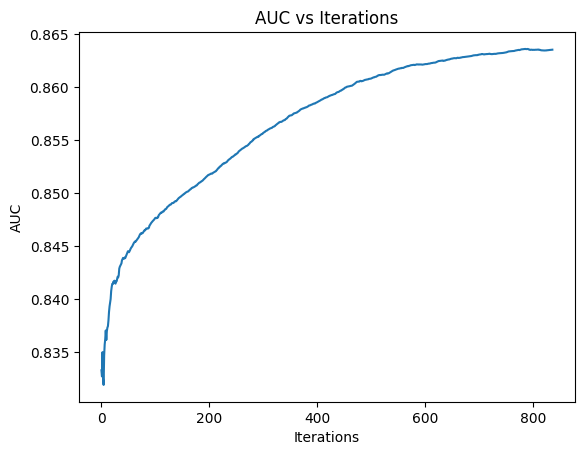

In [33]:
import matplotlib.pyplot as plt
aucs = evals_result['valid_0']['auc']
iterations = list(range(len(aucs)))

plt.figure()
plt.plot(iterations, aucs)
plt.xlabel("Iterations")
plt.ylabel("AUC")
plt.title("AUC vs Iterations")
plt.show()

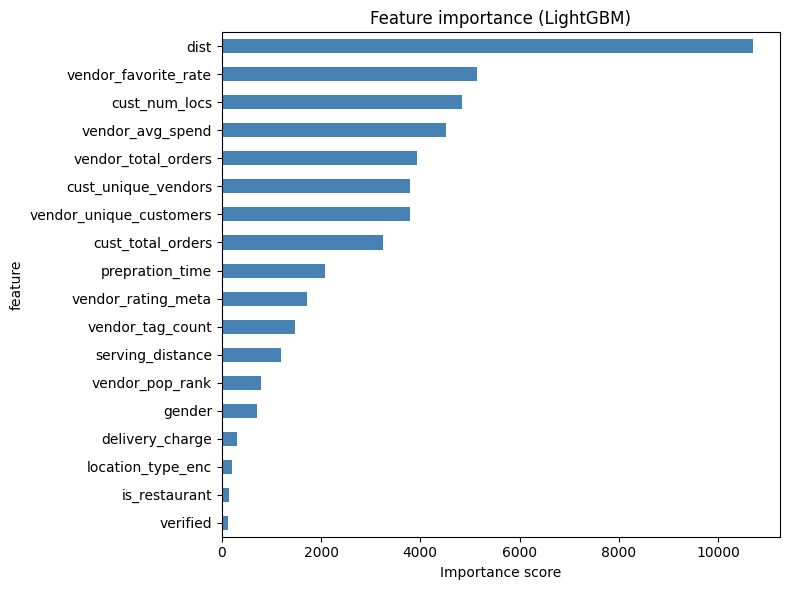

In [34]:
fi_df = pd.DataFrame(fi, columns=['feature', 'importance']).set_index('feature')

plt.figure(figsize=(8, 6))
fi_df['importance'].sort_values().plot(kind='barh', color='steelblue')
plt.title('Feature importance (LightGBM)')
plt.xlabel('Importance score')
plt.tight_layout()
plt.show()

In [35]:
print("\nPredicting on test set...")
 
for c in FEATURE_COLS:
    test_full[c] = test_full[c].fillna(medians[c]).astype(np.float32)
 
BATCH_SIZE = 200_000 #reduce if memory issues
scores = []
 
for i in range(0, len(test_full), BATCH_SIZE):
    batch = test_full[FEATURE_COLS].iloc[i : i + BATCH_SIZE].values
    scores.append(model.predict_proba(batch)[:, 1])
 
test_full["score"] = np.concatenate(scores)


Predicting on test set...


In [36]:
# Popularity baseline: predicting based on top-3 globally popular vendors to everyone
top3 = orders.groupby('vendor_id').size().nlargest(3).index.tolist()
train_val['baseline'] = train_val['vendor_id'].isin(top3).astype(int)
baseline_precision = (train_val['target'] & train_val['baseline']).sum() / train_val['baseline'].sum()
print(f"Popularity baseline Precision@3: {baseline_precision:.4f}")
print(f"Your model Precision@3:          0.2906")
print(f"Improvement:                     {0.2906/baseline_precision:.2f}x")

Popularity baseline Precision@3: 0.2568
Your model Precision@3:          0.2906
Improvement:                     1.13x


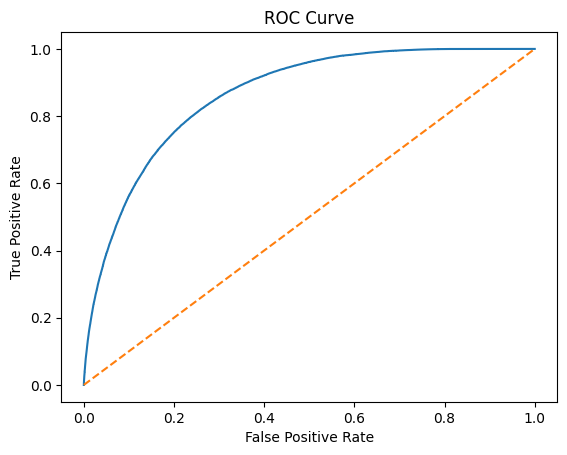

In [37]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_val, val_preds)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle='--')  # random baseline
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

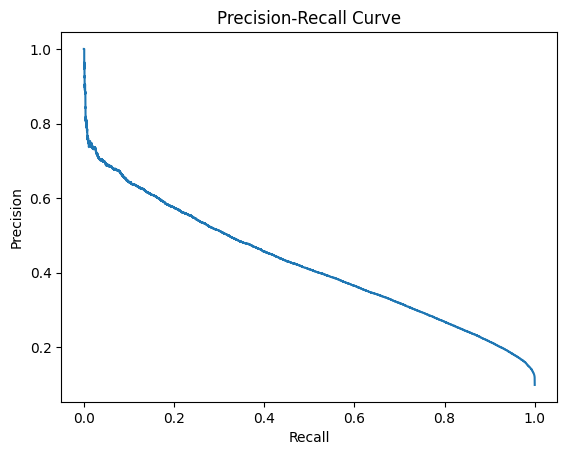

In [38]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_val, val_preds)

plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

In [39]:
# Attach predictions back
train_val["pred"] = val_preds

# Rank vendors per (customer, location)
train_val["rank"] = train_val.groupby(["customer_id", "location_number"])["pred"]\
    .rank(method="first", ascending=False)

K = 3
train_val["pred_label"] = (train_val["rank"] <= K).astype(int)

# Precision@K
precision_at_k = (train_val["target"] & train_val["pred_label"]).sum() / train_val["pred_label"].sum()

print(f"Precision@{K}: {precision_at_k:.4f}")

Precision@3: 0.2906


In [40]:
recall_at_k = (train_val["target"] & train_val["pred_label"]).sum() / train_val["target"].sum()

print(f"Recall@{K}: {recall_at_k:.4f}")

Recall@3: 0.2716


In [41]:
from sklearn.metrics import f1_score

f1 = f1_score(train_val["target"], train_val["pred_label"])
print(f"F1 Score: {f1:.4f}")

F1 Score: 0.2808


In [42]:
precisions = []
ks = [1, 2, 3, 5]

for K in ks:
    train_val["rank"] = train_val.groupby(["customer_id", "location_number"])["pred"]\
        .rank(method="first", ascending=False)
    
    train_val["pred_label"] = (train_val["rank"] <= K).astype(int)
    
    precision_k = (train_val["target"] & train_val["pred_label"]).sum() / train_val["pred_label"].sum()
    precisions.append(precision_k)

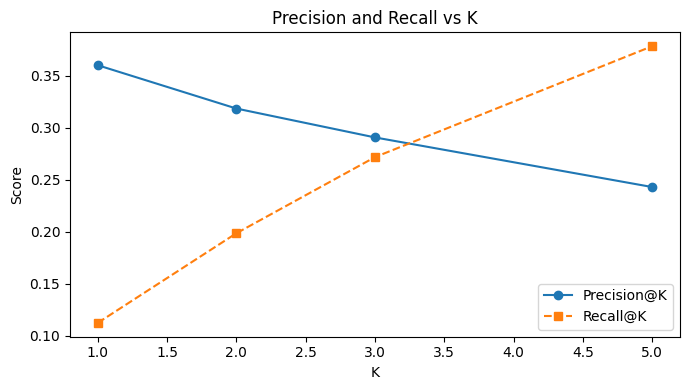

In [43]:
recalls = []
for K in ks:
    train_val['rank'] = train_val.groupby(['customer_id','location_number'])['pred']\
        .rank(method='first', ascending=False)
    train_val['pred_label'] = (train_val['rank'] <= K).astype(int)
    recall_k = (train_val['target'] & train_val['pred_label']).sum() / train_val['target'].sum()
    recalls.append(recall_k)

plt.figure(figsize=(7, 4))
plt.plot(ks, precisions, marker='o', label='Precision@K')
plt.plot(ks, recalls,   marker='s', label='Recall@K', linestyle='--')
plt.xlabel('K')
plt.ylabel('Score')
plt.title('Precision and Recall vs K')
plt.legend()
plt.tight_layout()
plt.show()

K=1 maximises precision, K=3 balances precision and recall..

In [44]:
TOP_K = 3   # ← number of vendors to recommend per (customer, location)
 
test_full["rank"] = test_full.groupby(["customer_id", "location_number"])["score"].rank(
    method="first", ascending=False
)
test_full["target"] = (test_full["rank"] <= TOP_K).astype(int)
 
submission = test_full[["CID X LOC_NUM X VENDOR", "target"]].copy()
submission.to_csv("submission.csv", index=False)
 
print(f"\nSubmission saved → submission.csv")
print(f"  Total rows:   {len(submission):,}")
print(f"  Recommended:  {submission['target'].sum():,} ({submission['target'].mean():.2%})")


Submission saved → submission.csv
  Total rows:   1,673,600
  Recommended:  50,160 (3.00%)


This LightGBM model achieves Precision@3 of 0.2906 on held-out customers, compared to 0.2568 for a strong popularity baseline - a 13% improvement. This is meaningful because all test customers are cold-start (zero order history), making the task fundamentally harder than a standard recommendation problem. The model succeeds by learning that proximity (distance) is the dominant driver of food delivery choices, followed by vendor-level quality signals like favourite rate and popularity. A validation AUC of 0.8636 confirms the model generalises well to unseen customers, correctly separating positive from negative vendor pairs 86% of the time despite having no user-specific behavioural data to work with.

We can include checking if the customer is in serving range of the vendor, and use it also for the prediction. Later, I would like to experiment trying to convertig the sparse data into vectors embeddings and use them to train a model.